In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']=(14,5)
plt.rcParams['figure.dpi']=100

df=pd.read_csv('../outputs/clean_data.csv',parse_dates=['InvoiceDate'])

print("\nShape:",df.shape)
print("Date range:", df['InvoiceDate'].min().date() ,"->", df['InvoiceDate'].max().date())
print("Unique cutomers:",df['CustomerID'].nunique())
df.head()


Shape: (369762, 9)
Date range: 2010-12-01 -> 2011-12-09
Unique cutomers: 4228


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:
#Reference date - the day after last transaction

reference_date=df['InvoiceDate'].max()+ pd.Timedelta(days=1)
print("Reference Date:",reference_date.date())

Reference Date: 2011-12-10


In [3]:
rfm=df.groupby('CustomerID').agg(
    Recency=('InvoiceDate',lambda x: (reference_date-x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue','sum')    
).reset_index()

print("RFM Table Shape: ", rfm.shape)
print("\nSample: ")
print(rfm.head(10))
print("\nBasic Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

RFM Table Shape:  (4228, 4)

Sample: 
   CustomerID  Recency  Frequency  Monetary
0       12347        2          7   3783.23
1       12348      249          3     90.20
2       12349       19          1   1328.55
3       12350      310          1    294.40
4       12352       36          7   1321.99
5       12353      204          1     89.00
6       12354      232          1   1013.60
7       12355      214          1    238.90
8       12356       23          3   1778.89
9       12357       33          1   4817.23

Basic Statistics:
       Recency  Frequency   Monetary
count  4228.00    4228.00    4228.00
mean     92.60       4.09    1255.86
std     100.23       7.19    2812.55
min       1.00       1.00       2.90
25%      18.00       1.00     250.17
50%      51.00       2.00     563.19
75%     143.25       4.00    1351.11
max     374.00     201.00  105017.20


In [4]:
#Average Order Value (AOV)
aov=df.groupby('CustomerID').agg(AOV=('Revenue','mean')).reset_index()

#Unique Products Purchased
products=df.groupby('CustomerID').agg(
    UniqueProducts=('StockCode','nunique')
).reset_index()

#Customer Lifespan (First Purchase to Last Purchase)
lifespan=df.groupby('CustomerID').agg(
    FirstPurchase=('InvoiceDate','min'),
    LastPurchase=('InvoiceDate','max')
).reset_index()
lifespan['Lifespan']=(lifespan['LastPurchase']-lifespan['FirstPurchase']).dt.days

#Average Number of Days Between Orders
#Frequency/Lifespan gives purchase cadence
lifespan=lifespan.merge(rfm[['CustomerID','Frequency']],on='CustomerID', how='left')
lifespan['AvgDaysBetweenOrders']=lifespan.apply(
    lambda x: x['Lifespan']/(x['Frequency']-1)
    if x['Frequency']>1 else 0,
    axis=1
)

#Merge to rfm
customer_df=rfm.copy()
customer_df=customer_df.merge(aov, on='CustomerID',how='left')
customer_df=customer_df.merge(products,on='CustomerID', how='left')
customer_df=customer_df.merge(
    lifespan[['CustomerID','Lifespan','AvgDaysBetweenOrders','FirstPurchase','LastPurchase']],on='CustomerID',how='left'
)

print("Customer feature table shape:",customer_df.shape)
print("\nColumns:",customer_df.columns.tolist())
print("\nSample:")
customer_df.head()


Customer feature table shape: (4228, 10)

Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'AvgDaysBetweenOrders', 'FirstPurchase', 'LastPurchase']

Sample:


,CustomerID,Recency,Frequency,Monetary,AOV,UniqueProducts,Lifespan,AvgDaysBetweenOrders,FirstPurchase,LastPurchase
0,12347,2,7,3783.23,21.495625,101,365,60.833333,2010-12-07 14:57:00,2011-12-07 15:52:00
1,12348,249,3,90.20,15.033333,6,109,54.500000,2010-12-16 19:09:00,2011-04-05 10:47:00
2,12349,19,1,1328.55,19.537500,68,0,0.000000,2011-11-21 09:51:00,2011-11-21 09:51:00
3,12350,310,1,294.40,18.400000,16,0,0.000000,2011-02-02 16:01:00,2011-02-02 16:01:00
4,12352,36,7,1321.99,17.626533,56,260,43.333333,2011-02-16 12:33:00,2011-11-03 14:37:00


In [5]:
#Convert Lifespan to years
customer_df['LifespanYears']=(customer_df['Lifespan']/365).clip(lower=0)

#CLTV target
customer_df['CLTV']=(
    customer_df['Frequency']*customer_df['AOV']*(customer_df['LifespanYears']+1)
)

print("CLTV statistics:")
print(customer_df['CLTV'].describe().round(2))
print(f"\nMin CLTV: £{customer_df['CLTV'].min():.2f}")
print(f"Max CLTV: £{customer_df['CLTV'].max():.2f}")
print(f"Mean CLTV: £{customer_df['CLTV'].mean():.2f}")
print(f"Median CLTV: £{customer_df['CLTV'].median():.2f}")

customer_df['CLTV_Tier']=pd.qcut(
    customer_df['CLTV'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

print("\nCLTV Tier Distribution:")
print(customer_df['CLTV_Tier'].value_counts())

CLTV statistics:
count    4228.00
mean      140.31
std       377.15
min         1.45
25%        17.24
50%        45.62
75%       123.22
max      8125.26
Name: CLTV, dtype: float64

Min CLTV: £1.45
Max CLTV: £8125.26
Mean CLTV: £140.31
Median CLTV: £45.62

CLTV Tier Distribution:
CLTV_Tier
Low     1410
Mid     1409
High    1409
Name: count, dtype: int64


In [6]:
#Threshold: customer churned if last purchase > 90 days ago
CHURN_THRESHOLD=90

customer_df['Churned']=(customer_df['Recency']>CHURN_THRESHOLD).astype(int)

churn_rate= (customer_df['Churned'].mean())*100
print(f"Churn Threshold: {CHURN_THRESHOLD} days")
print(f"Churned Customers: {customer_df['Churned'].sum()} customers")
print(f"Active Customers: {(customer_df['Churned']==0).sum()}")
print(f"Churn Rate: {churn_rate:.1f} %")


Churn Threshold: 90 days
Churned Customers: 1401 customers
Active Customers: 2827
Churn Rate: 33.1 %


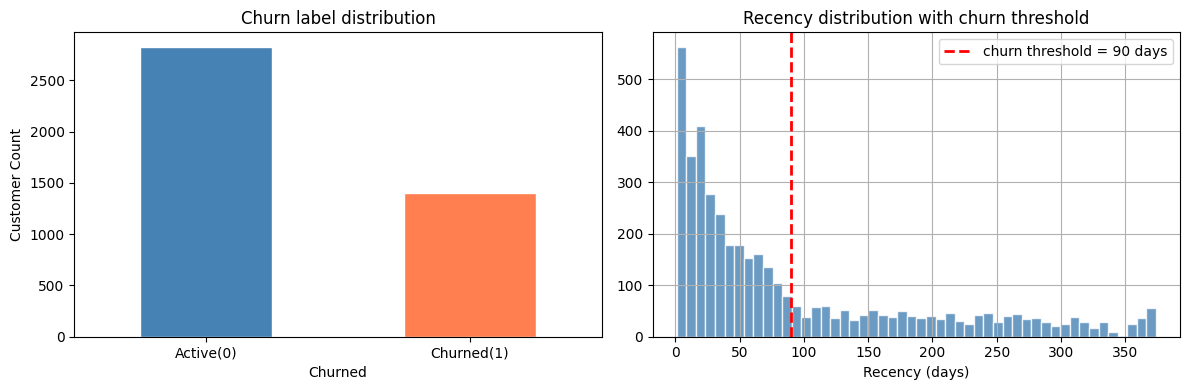

In [7]:
fig, axes=plt.subplots(1,2, figsize=(12,4))

customer_df['Churned'].value_counts().plot(
    kind='bar', ax=axes[0],color=['steelblue','coral'],edgecolor='white'
)

axes[0].set_xticklabels(["Active(0)", "Churned(1)"], rotation=0)
axes[0].set_title("Churn label distribution")
axes[0].set_ylabel("Customer Count")

#Recency distribution with churn threshold line
customer_df['Recency'].hist(
    bins=50, ax=axes[1],color='steelblue', edgecolor='white',alpha=0.8
)

axes[1].axvline(CHURN_THRESHOLD,color='red',linestyle='--',linewidth=2, label=f"churn threshold = {CHURN_THRESHOLD} days")
axes[1].set_title("Recency distribution with churn threshold")
axes[1].set_xlabel("Recency (days)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/churn_label_distribution.png",dpi=100, bbox_inches='tight')
plt.show()


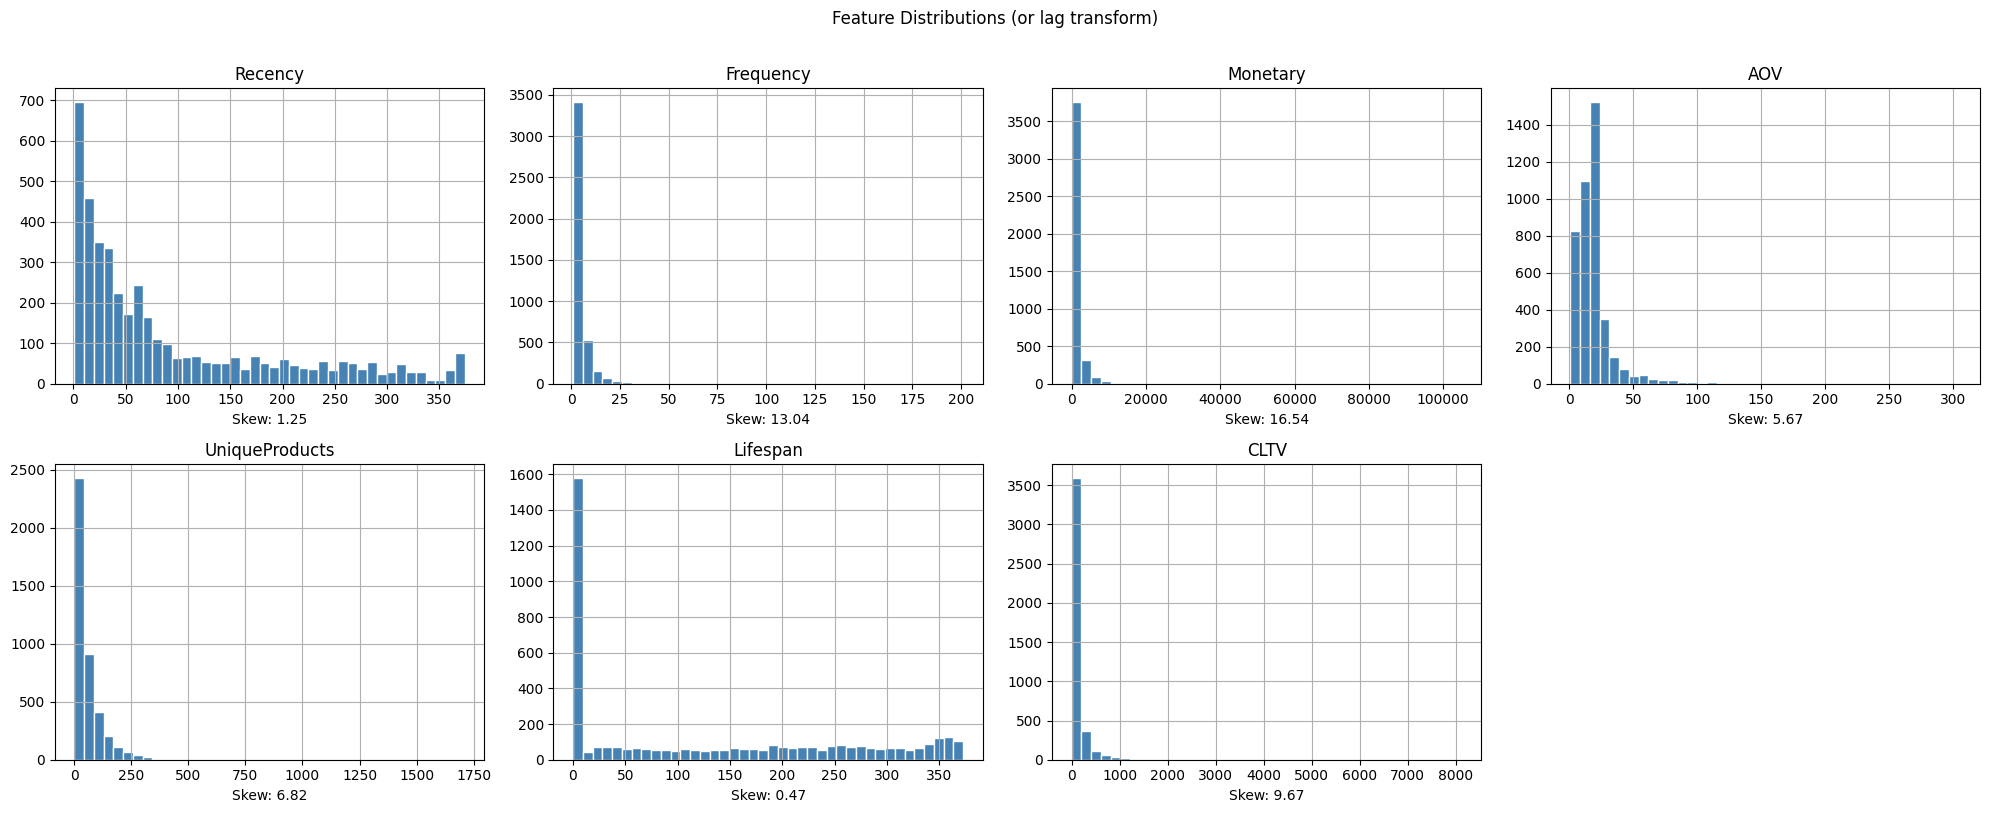

In [8]:
features_to_plot=['Recency','Frequency','Monetary','AOV','UniqueProducts','Lifespan','CLTV']

fig, axes= plt.subplots(2,4,figsize=(20,8))
axes=axes.flatten()

for i, col in enumerate(features_to_plot):
    customer_df[col].hist(bins=40, ax=axes[i], color='steelblue',edgecolor='white')
    axes[i].set_title(col)
    skew_val=customer_df[col].skew()
    axes[i].set_xlabel(f'Skew: {skew_val:.2f}')
    
axes[-1].axis('off')
plt.suptitle('Feature Distributions (or lag transform)',y=1.01)
plt.tight_layout()
plt.savefig("../outputs/feature_distribution_raw.png",dpi=100, bbox_inches='tight')
plt.show()


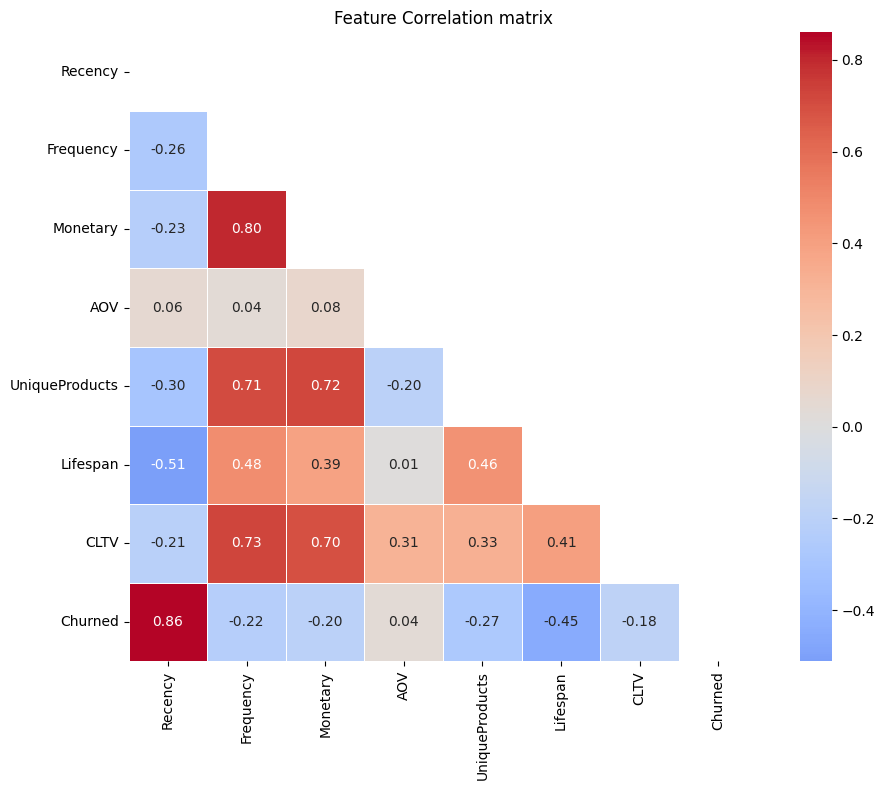

In [9]:
numeric_cols=['Recency', 'Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'CLTV', 'Churned']

plt.figure(figsize=(10,8))

corr=customer_df[numeric_cols].corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True )
plt.title("Feature Correlation matrix")
plt.tight_layout()
plt.savefig("../outputs/feature_correlation.png",dpi=100,bbox_inches='tight')
plt.show()


In [10]:
skew_before=customer_df[['Recency','Frequency','Monetary','AOV','CLTV']].skew()
print("Skew before log transform:")
print(skew_before.round(3))

Skew before log transform:
Recency       1.247
Frequency    13.043
Monetary     16.542
AOV           5.668
CLTV          9.670
dtype: float64


In [11]:
#log transformation
log_cols=customer_df[['Recency','Frequency','Monetary','AOV','CLTV']]

for col in log_cols:
    customer_df[f"Log_{col}"]=np.log1p(customer_df[col])
    
log_col_names=[f'Log_{c}' for c in log_cols]
skew_after=customer_df[log_col_names].skew()
print("\nSkew after log transform:")
print(skew_after.round(3))


Skew after log transform:
Log_Recency     -0.377
Log_Frequency    1.183
Log_Monetary     0.018
Log_AOV          0.113
Log_CLTV         0.457
dtype: float64


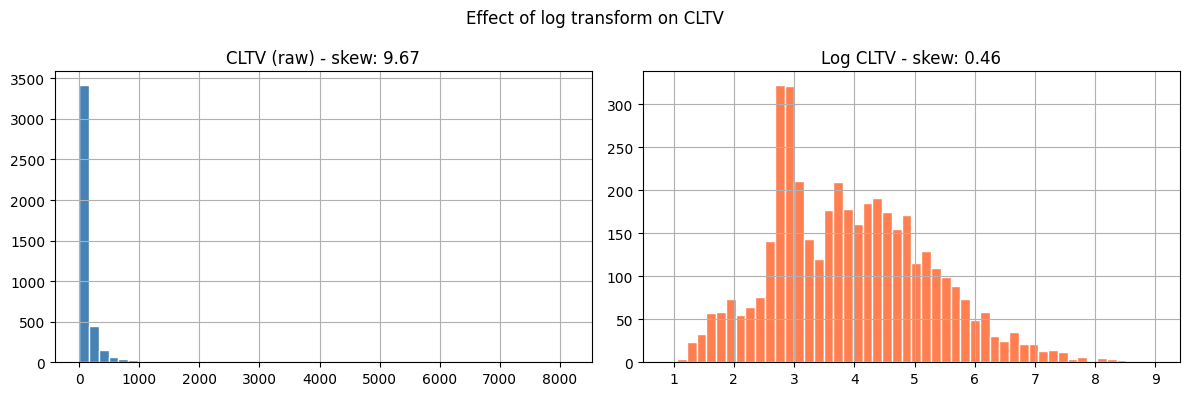

In [12]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

customer_df['CLTV'].hist(bins=50,ax=axes[0],color='steelblue',edgecolor='white')
axes[0].set_title(f"CLTV (raw) - skew: {customer_df['CLTV'].skew():.2f}")

customer_df['Log_CLTV'].hist(bins=50, ax=axes[1],color='coral', edgecolor='white')
axes[1].set_title(f"Log CLTV - skew: {customer_df['Log_CLTV'].skew():.2f}")

plt.suptitle('Effect of log transform on CLTV')
plt.tight_layout()
plt.savefig('../outputs/log_transform_cltv.png',dpi=100,bbox_inches='tight')
plt.show()

In [15]:
#Drop helper columns
customer_df=customer_df.drop(columns=['FirstPurchase','LastPurchase','LifespanYears'], errors='ignore')

print("Final Columns:")
for col in customer_df.columns:
    print(f"  {col:<25} {customer_df[col].dtype}")

print(f"\nFinal shape: {customer_df.shape}")
print(f"Unique customers: {customer_df['CustomerID'].nunique()}")
print(f"\nNull values remaining:")
print(customer_df.isnull().sum()[customer_df.isnull().sum() >0])

Final Columns:
  CustomerID                int64
  Recency                   int64
  Frequency                 int64
  Monetary                  float64
  AOV                       float64
  UniqueProducts            int64
  Lifespan                  int64
  AvgDaysBetweenOrders      float64
  CLTV                      float64
  CLTV_Tier                 category
  Churned                   int32
  Log_Recency               float64
  Log_Frequency             float64
  Log_Monetary              float64
  Log_AOV                   float64
  Log_CLTV                  float64

Final shape: (4228, 16)
Unique customers: 4228

Null values remaining:
Series([], dtype: int64)


In [16]:
customer_df.to_csv('../outputs/customer_features.csv', index=False)
print("Saved to ../outputs/customer_features.csv")

Saved to ../outputs/customer_features.csv
